In [200]:
import numpy as np
from bitarray import bitarray

In [201]:
def run_lenght_compressor(array, counter_size=8):

    max_encoded_values = (2 ** counter_size)-1
    compressed_array = ''

    counter = None
    current_bit = None

    for i, bit in enumerate(array):
        if i == 0:
            current_bit = bit
            counter = 1
        elif current_bit != bit or counter == max_encoded_values:
            #Añadir conteo de apariciones al vector
            counter_str = str(bin(counter)[2:])
            counter_str = counter_str.zfill(counter_size)

            compressed_array += counter_str
            compressed_array += str(current_bit)

            current_bit = bit
            counter = 1
        else:
            counter += 1

    counter_str = str(bin(counter)[2:])
    counter_str = counter_str.zfill(counter_size)

    compressed_array += counter_str
    compressed_array += str(current_bit)

    return bitarray(compressed_array)

In [202]:
def run_lenght_decompressor(array, counter_size=8):

    steps = len(array) // (counter_size+1)

    decompressed_array = ''

    for i in range(steps):
        position = i * (counter_size+1)

        counter = array[position:position+counter_size]
        bit = array[position+counter_size]

        counter = int(counter.to01(), 2)

        decompressed_array += counter * str(bit)
        
    return bitarray(decompressed_array)

In [203]:
#array = bitarray('0000001111111110000001000101001100000000111111110000111100000000')
array = bitarray('0000001111111110000000000000000000000000111111110000111100000000')
#array = bitarray('0000001111111110000001000101')

block_size = 4

compressed_array = run_lenght_compressor(array, block_size)
#compressed_array = bitarray(compressed_array)

decompressed_array = run_lenght_decompressor(compressed_array, block_size)
#decompressed_array = bitarray(decompressed_array)

print("RAW")
print(array)
print(f"Bits: {len(array)}")  
print(f"Bytes: {len(array.tobytes())}\n")

print("COMPRIMIDO")
print(compressed_array)
print("Tamaño del bloque (bits): "+str(block_size))
print(f"Bits: {len(compressed_array)}")  
print(f"Bytes: {len(compressed_array.tobytes())}\n")

print("ESTADISTICAS")
#print(decompressed_array)
print("Compresion correcta: "+str(array==decompressed_array))
print("Tamaño final: "+str(len(compressed_array)/len(array)))

RAW
bitarray('0000001111111110000000000000000000000000111111110000111100000000')
Bits: 64
Bytes: 8

COMPRIMIDO
bitarray('0110010011111101010010001010000100110000')
Tamaño del bloque (bits): 4
Bits: 40
Bytes: 5

ESTADISTICAS
Compresion correcta: True
Tamaño final: 0.625


In [204]:
def count_lenght_sequences(array):
    counter = 0
    current_item = None

    lenghts = {}

    for i, item in enumerate(array):
        if i == 0:
            current_item = item
            counter = 1
        elif current_item!=item:
            if counter not in lenghts.keys():
                lenghts[counter]=1
            else:
                lenghts[counter]=lenghts[counter]+1

            current_item = item
            counter=1
        else:
            counter +=1

    return lenghts

In [205]:
def count_occurrences(array):
    occurrences = {}

    for item in array:
        if item not in occurrences.keys():
            occurrences[item]=1
        else:
            occurrences[item]=occurrences[item]+1

    return occurrences

In [206]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

def show_histogram(datos):
    # Claves y valores del diccionario
    etiquetas = list(datos.keys())
    valores = list(datos.values())

    # Crear la gráfica de barras
    plt.bar(etiquetas, valores)
    plt.xlabel("Categorías")
    plt.ylabel("Frecuencia")
    plt.title("Histograma")

    plt.gca().xaxis.set_major_locator(ticker.MaxNLocator(integer=True))

    plt.show()


In [207]:
from bitarray import bitarray
from bitarray.util import ba2int

def split_into_sequences(array, size=8):

    steps = len(array) // size

    sequence = []

    for i in range(steps):
        position = i * size

        sequence.append(ba2int(array[position:position+size]))

    if steps * size < len(array):
        sequence.append(ba2int(array[steps:len(array)]))

    return sequence

In [208]:
import torch

hdv_prototypes_path = "/home/joselu/Universidad/Master_RISCV/TFM/HDC_Accelerator/prototypes"
node = 4
normalized = "_NOT"
normalized = ""

array = torch.load(f'{hdv_prototypes_path}/node_{int(node)}{normalized}_normalized.pt', weights_only=False)

array = array.numpy()

print("Tamaño del vector: "+str(len(array)))

lengths=count_lenght_sequences(array)
print(lengths)

Tamaño del vector: 10000
{3: 575, 1: 2520, 5: 150, 4: 310, 2: 1228, 6: 82, 7: 46, 8: 22, 9: 16, 13: 2, 12: 4, 10: 5, 11: 3, 17: 1}


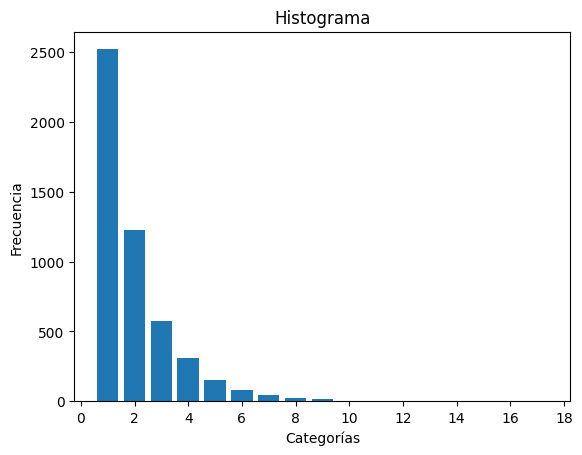

In [209]:
show_histogram(lengths)

In [210]:
import torch
import os
from collections import Counter
from bitarray import bitarray
from bitarray.util import int2ba

hdv_prototypes_path = "/home/joselu/Universidad/Master_RISCV/TFM/HDC_Accelerator/prototypes"

files = [f for f in os.listdir(hdv_prototypes_path) if os.path.isfile(os.path.join(hdv_prototypes_path, f))]

normalized_files = [f for f in files if "NOT" not in f]
not_normalized_files = [f for f in files if "NOT" in f]

print(normalized_files)
print(not_normalized_files)

['node_120_normalized.pt', 'node_81_normalized.pt', 'node_150_normalized.pt', 'node_133_normalized.pt', 'node_39_normalized.pt', 'node_20_normalized.pt', 'node_50_normalized.pt', 'node_192_normalized.pt', 'node_149_normalized.pt', 'node_14_normalized.pt', 'node_25_normalized.pt', 'node_89_normalized.pt', 'node_113_normalized.pt', 'node_194_normalized.pt', 'node_142_normalized.pt', 'node_16_normalized.pt', 'node_123_normalized.pt', 'node_88_normalized.pt', 'node_162_normalized.pt', 'node_184_normalized.pt', 'node_85_normalized.pt', 'node_132_normalized.pt', 'node_33_normalized.pt', 'node_38_normalized.pt', 'node_118_normalized.pt', 'node_151_normalized.pt', 'node_87_normalized.pt', 'node_153_normalized.pt', 'node_86_normalized.pt', 'node_77_normalized.pt', 'node_189_normalized.pt', 'node_40_normalized.pt', 'node_75_normalized.pt', 'node_54_normalized.pt', 'node_24_normalized.pt', 'node_8_normalized.pt', 'node_117_normalized.pt', 'node_18_normalized.pt', 'node_78_normalized.pt', 'node_11

In [211]:
all_arrays=[]

for file in normalized_files:
    try:
        array = torch.load(f'{hdv_prototypes_path}/{file}', weights_only=False)
        array = array.numpy()

        #Pasar de (-1, 1) a (0, 1)
        array = (array + 1)//2

        bit_array = bitarray()

        for n in array:
            bit_array.extend(str(n))

        all_arrays.append(bit_array)
    except Exception as e:
        print(str(e))

'NoneType' object has no attribute 'numpy'
'NoneType' object has no attribute 'numpy'
'NoneType' object has no attribute 'numpy'
'NoneType' object has no attribute 'numpy'
'NoneType' object has no attribute 'numpy'
'NoneType' object has no attribute 'numpy'
'NoneType' object has no attribute 'numpy'
'NoneType' object has no attribute 'numpy'
'NoneType' object has no attribute 'numpy'
'NoneType' object has no attribute 'numpy'
'NoneType' object has no attribute 'numpy'
'NoneType' object has no attribute 'numpy'
'NoneType' object has no attribute 'numpy'
'NoneType' object has no attribute 'numpy'
'NoneType' object has no attribute 'numpy'
'NoneType' object has no attribute 'numpy'


In [212]:
all_lenghts = {}

for array in all_arrays:
    lengths = count_lenght_sequences(array)
    all_lenghts = dict(Counter(all_lenghts)+Counter(lengths))

print(all_lenghts)

{5: 16139, 2: 126006, 1: 256654, 3: 59846, 6: 7641, 4: 31284, 9: 1275, 8: 2036, 7: 4846, 10: 820, 11: 293, 13: 150, 12: 169, 17: 77, 15: 56, 14: 49, 16: 6}


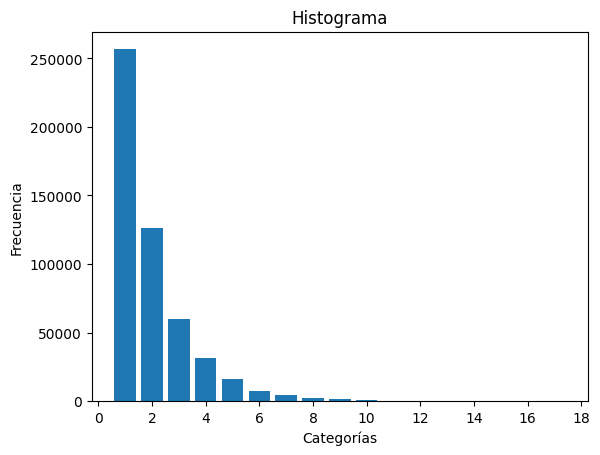

In [213]:
show_histogram(all_lenghts)

In [219]:
all_occurrences = {}

for array in all_arrays:
    sequences = split_into_sequences(array, 4)
    occurences = count_occurrences(sequences)
    all_occurrences = dict(Counter(all_occurrences)+Counter(occurences))

print(all_occurrences)

{15: 8126000, 14: 211467, 6: 97719, 2: 172510, 0: 6476785, 1: 157411, 8: 59920, 12: 125103, 4: 145717, 10: 142161, 5: 120218, 3: 80278, 11: 153530, 13: 134344, 7: 43679, 9: 73158}


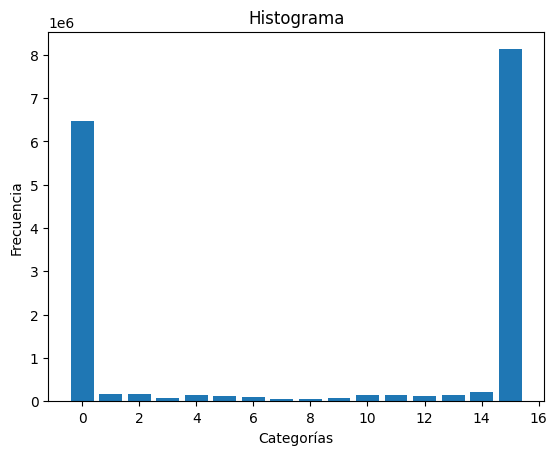

In [220]:
show_histogram(all_occurrences)

In [216]:
all_arrays = []

for file in not_normalized_files:
    try:
        array = torch.load(f'{hdv_prototypes_path}/{file}', weights_only=False)
        array = array.numpy()

        bit_array = bitarray()

        for n in array:
            bit_array.extend(int2ba(int(n), length=64, endian='big', signed=True))

        all_arrays.append(bit_array)

    except Exception as e:
        print("Error al cargar el archivo: "+str(file)+" "+str(e))

In [217]:
all_lenghts = {}

for array in all_arrays:
    lengths = count_lenght_sequences(array)
    all_lenghts = dict(Counter(all_lenghts)+Counter(lengths))

print(all_lenghts)

{59: 227849, 2: 678223, 1: 1905325, 3: 258550, 60: 158508, 4: 126158, 63: 48773, 62: 68146, 65: 4057, 61: 82840, 64: 14149, 124: 373, 125: 519, 127: 583, 128: 219, 66: 1577, 126: 664, 188: 3, 67: 548, 57: 180385, 58: 226261, 6: 5016, 5: 50396, 122: 134, 123: 320, 68: 186, 69: 86, 129: 149, 130: 34, 189: 15, 193: 13, 191: 47, 190: 55, 192: 17, 255: 7, 131: 26, 253: 5, 384: 1, 254: 6, 194: 5, 256: 4, 70: 9, 187: 1, 132: 2, 320: 1, 319: 1, 257: 1, 252: 1}


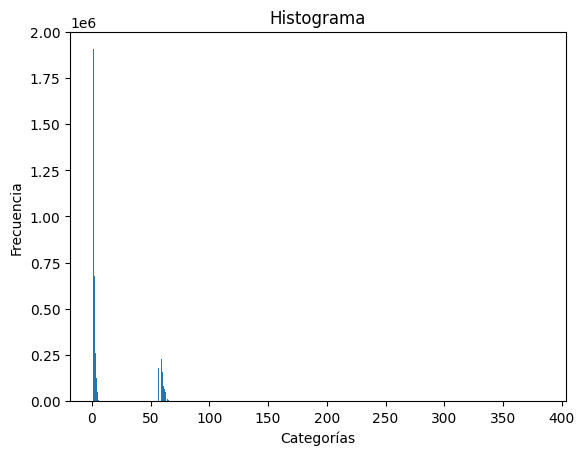

In [218]:
show_histogram(all_lenghts)